In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI()

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):
    #take user query from state
    messages = state['messages']
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}

In [13]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

#add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)


chatbot = graph.compile(checkpointer=checkpoint)

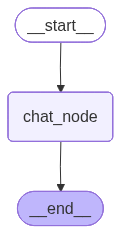

In [14]:
chatbot

In [31]:
thread_id = "2"
initial_state = {
    'messages': [HumanMessage(content='What is my name?')]
}

config = {'configurable': {'thread_id': thread_id}}
response = chatbot.invoke(initial_state, config=config)

In [32]:
response['messages'][-1].content

'Your name is Alex.'

In [33]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='a01d2669-0a59-4e0e-8af8-12af54baccc8'), AIMessage(content="I'm sorry, I do not know what your name is as I am an AI assistant and do not have access to your personal information.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 12, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Dl6183gJx0kEGbN4PJZUz2pq6kWxb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e773c-90fd-7880-b687-3ccf44fd544e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_token

In [ ]:
thread_id = "1"

while True:
    user_message = input('Type here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI:', response['messages'][-1].content)